# Object Dropped / Launched from a Building

Change the building height and the object's initial velocity, then press **Run animation**.

The display has a fixed size. If the object leaves the visible region, it simply disappears from the frame.

In [9]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

g = 9.81


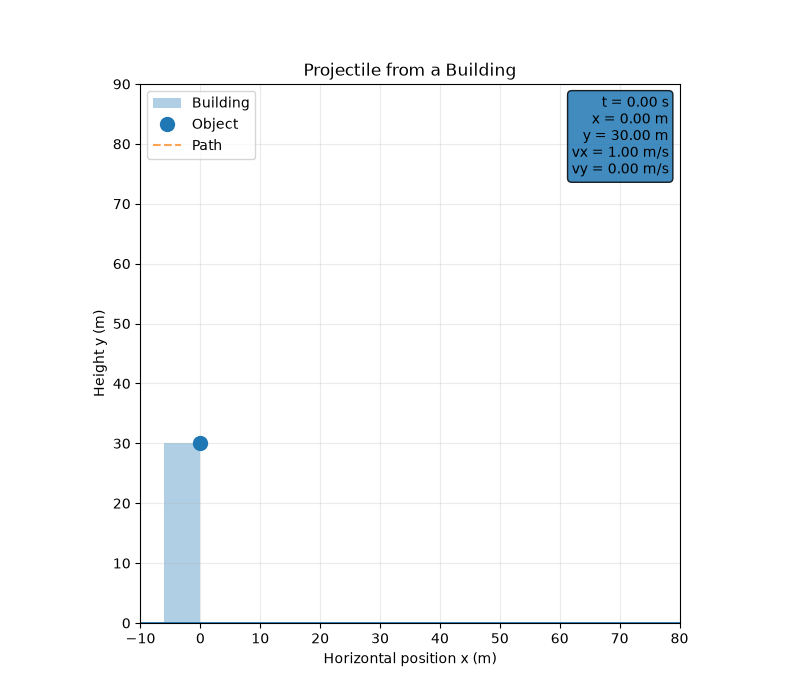

In [11]:
# Controls
height = widgets.FloatSlider(
    value=30, min=5, max=80, step=1,
    description='Height (m):', continuous_update=False,
    style={'description_width': '100px'}, layout=widgets.Layout(width='420px')
)

vx0 = widgets.FloatSlider(
    value=1, min=-25, max=25, step=1,
    description='Initial vx:', continuous_update=False,
    style={'description_width': '100px'}, layout=widgets.Layout(width='420px')
)

vy0 = widgets.FloatSlider(
    value=0, min=-25, max=25, step=1,
    description='Initial vy:', continuous_update=False,
    style={'description_width': '100px'}, layout=widgets.Layout(width='420px')
)

run_button = widgets.Button(description='Run animation', button_style='primary')
reset_button = widgets.Button(description='Reset')

display(widgets.VBox([
    height,
    vx0,
    vy0,
    widgets.HBox([run_button, reset_button])
]))

# Fixed animation frame
X_MIN, X_MAX = -10, 80
Y_MIN, Y_MAX = 0, 90

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Horizontal position x (m)')
ax.set_ylabel('Height y (m)')
ax.set_title('Projectile from a Building')
ax.grid(alpha=0.25)

# Ground
ax.axhline(0, linewidth=2)

# Artists that will be updated
building_patch = Rectangle((-6, 0), 6, height.value, alpha=0.35, label='Building')
ax.add_patch(building_patch)

object_point, = ax.plot([], [], 'o', markersize=10, label='Object')
trail, = ax.plot([], [], '--', linewidth=1.5, alpha=0.7, label='Path')

info = ax.text(
    0.98, 0.98, '', transform=ax.transAxes,
    ha='right', va='top',
    bbox=dict(boxstyle='round', alpha=0.85)
)

ax.legend(loc='upper left')

animation = None

def make_trajectory():
    H = height.value
    vx = vx0.value
    vy = vy0.value

    # Solve H + vy*t - 1/2*g*t^2 = 0 for impact time
    t_hit = (vy + np.sqrt(vy**2 + 2*g*H)) / g
    t = np.linspace(0, t_hit, max(80, int(t_hit * 35)))
    x = vx * t
    y = H + vy*t - 0.5*g*t**2
    v_y = vy - g*t
    speed = np.sqrt(vx**2 + v_y**2)
    return t, x, y, v_y, speed

def draw_initial_state():
    H = height.value
    building_patch.set_height(H)
    object_point.set_data([0], [H])
    trail.set_data([], [])
    info.set_text(
        f't = 0.00 s\n'
        f'x = 0.00 m\n'
        f'y = {H:.2f} m\n'
        f'vx = {vx0.value:.2f} m/s\n'
        f'vy = {vy0.value:.2f} m/s'
    )
    fig.canvas.draw_idle()

def run_animation(_=None):
    global animation
    t, x, y, v_y, speed = make_trajectory()
    building_patch.set_height(height.value)

    def update(i):
        xi, yi = x[i], y[i]

        # Object disappears if it is outside the fixed visible frame
        visible = (X_MIN <= xi <= X_MAX) and (Y_MIN <= yi <= Y_MAX)
        if visible:
            object_point.set_data([xi], [yi])
        else:
            object_point.set_data([], [])

        # Only show the portion of the path inside the frame
        mask = ((x[:i+1] >= X_MIN) & (x[:i+1] <= X_MAX) &
                (y[:i+1] >= Y_MIN) & (y[:i+1] <= Y_MAX))
        trail.set_data(x[:i+1][mask], y[:i+1][mask])

        info.set_text(
            f't = {t[i]:.2f} s\n'
            f'x = {xi:.2f} m\n'
            f'y = {max(yi, 0):.2f} m\n'
            f'vx = {vx0.value:.2f} m/s\n'
            f'vy = {v_y[i]:.2f} m/s\n'
            f'speed = {speed[i]:.2f} m/s'
        )
        return object_point, trail, info

    animation = FuncAnimation(
        fig, update, frames=len(t), interval=10,
        blit=True, repeat=False
    )
    fig.canvas.draw_idle()

def reset_animation(_=None):
    global animation
    if animation is not None and animation.event_source is not None:
        animation.event_source.stop()
    draw_initial_state()

run_button.on_click(run_animation)
reset_button.on_click(reset_animation)
height.observe(lambda change: reset_animation(), names='value')
vx0.observe(lambda change: reset_animation(), names='value')
vy0.observe(lambda change: reset_animation(), names='value')

draw_initial_state()
plt.show()


## Physics used

$$
x(t)=v_{x0}t
$$

$$
y(t)=H+v_{y0}t-\frac{1}{2}gt^2
$$

Air resistance is ignored and $$g=9.81 \mathrm{m\,s^{-2}}$$